In [1]:
import pandas as pd
import numpy as np


In [2]:
df=pd.read_csv('/content/credit_risk_dataset.csv')

In [3]:
df.head(20)

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
6,26,77100,RENT,8.0,EDUCATION,B,35000,12.42,1,0.45,N,3
7,24,78956,RENT,5.0,MEDICAL,B,35000,11.11,1,0.44,N,4
8,24,83000,RENT,8.0,PERSONAL,A,35000,8.90,1,0.42,N,2
9,21,10000,OWN,6.0,VENTURE,D,1600,14.74,1,0.16,N,3


In [4]:
df.columns

Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')

In [5]:
df.rename(columns={'loan_amnt': 'loan_amount'}, inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amount                 32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.isnull()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amount,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,False,False,False,False,False,False,False,False,False,False,False,False
32577,False,False,False,False,False,False,False,False,False,False,False,False
32578,False,False,False,False,False,False,False,False,False,False,False,False
32579,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,895
loan_intent,0
loan_grade,0
loan_amount,0
loan_int_rate,3116
loan_status,0
loan_percent_income,0


In [9]:
df['person_emp_length'] = df['person_emp_length'].fillna(
    df['person_emp_length'].median()
)

In [10]:
df['loan_int_rate'] = df['loan_int_rate'].fillna(
    df['loan_int_rate'].mean()
)

In [11]:
df[['person_emp_length', 'loan_int_rate']].isnull().sum()

,0
person_emp_length,0
loan_int_rate,0


In [12]:
df.isnull().sum()

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amount,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['loan_grade'] = le.fit_transform(df['loan_grade'])

In [14]:
df = pd.get_dummies(df,columns=['loan_intent', 'person_home_ownership'], drop_first=True)

In [15]:
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y':1,'N':0})

In [16]:
df.head()

,person_age,person_income,person_emp_length,loan_grade,loan_amount,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT
0,22,59000,123.0,3,35000,16.02,1,0.59,1,3,False,False,False,True,False,False,False,True
1,21,9600,5.0,1,1000,11.14,0,0.10,0,2,True,False,False,False,False,False,True,False
2,25,9600,1.0,2,5500,12.87,1,0.57,0,3,False,False,True,False,False,False,False,False
3,23,65500,4.0,2,35000,15.23,1,0.53,0,2,False,False,True,False,False,False,False,True
4,24,54400,8.0,2,35000,14.27,1,0.55,1,4,False,False,True,False,False,False,False,True


In [17]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop('loan_status', axis=1)
y = df['loan_status']

In [19]:
### Data Preprocessing

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [20]:
from sklearn.preprocessing import StandardScaler

numeric_cols = [
    'person_age',
    'person_income',
    'person_emp_length',
    'loan_amount',
    'loan_int_rate',
    'loan_percent_income',
    'cb_person_cred_hist_length'
]

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

In [21]:
print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (22806, 17) (22806,)
Test set: (9775, 17) (9775,)


In [22]:
###Model Training

from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [23]:
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))


              precision    recall  f1-score   support

           0       0.93      0.79      0.86      7642
           1       0.52      0.79      0.62      2133

    accuracy                           0.79      9775
   macro avg       0.72      0.79      0.74      9775
weighted avg       0.84      0.79      0.81      9775

[[6058 1584]
 [ 450 1683]]
ROC-AUC: 0.8689644527436343


In [24]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report,confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts())
print("After SMOTE:", y_train_res.value_counts())

rf_smote = RandomForestClassifier(n_estimators=200, random_state=42)
rf_smote.fit(X_train_res, y_train_res)

y_pred_smote = rf_smote.predict(X_test)

print(classification_report(y_test, y_pred_smote))
print(confusion_matrix(y_test, y_pred_smote))
print("ROC-AUC:", roc_auc_score(y_test, rf_smote.predict_proba(X_test)[:,1]))

Before SMOTE: loan_status
0    17831
1     4975
Name: count, dtype: int64
After SMOTE: loan_status
0    17831
1    17831
Name: count, dtype: int64
              precision    recall  f1-score   support

           0       0.93      0.98      0.96      7642
           1       0.92      0.74      0.82      2133

    accuracy                           0.93      9775
   macro avg       0.93      0.86      0.89      9775
weighted avg       0.93      0.93      0.93      9775

[[7507  135]
 [ 549 1584]]
ROC-AUC: 0.9323377066040033


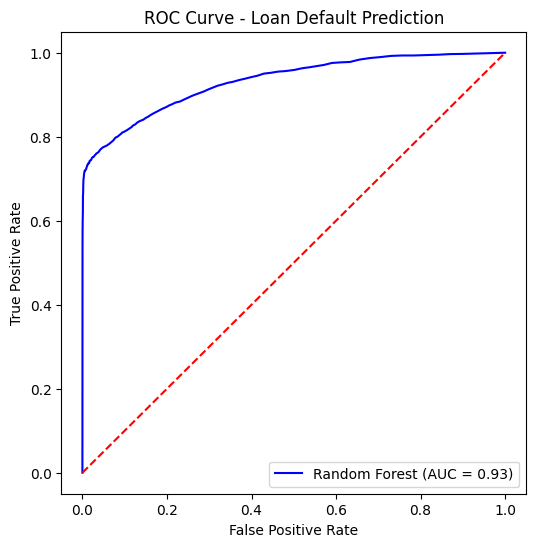

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_proba = rf_smote.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

## Model Evaluation
plt.figure(figsize=(6,6))
plt.plot(fpr,tpr,color='blue', label=f'Random Forest (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Loan Default Prediction')
plt.legend(loc="lower right")
plt.show()

<Axes: >

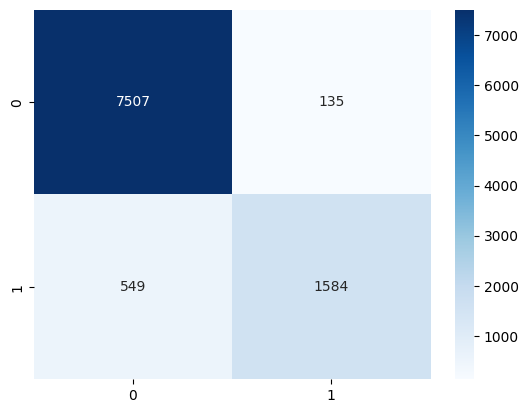

In [26]:
import seaborn as sns
sns.heatmap(confusion_matrix(y_test, y_pred_smote),annot=True, fmt='d', cmap='Blues')

In [27]:
print(y_train_res.value_counts())

loan_status
0    17831
1    17831
Name: count, dtype: int64


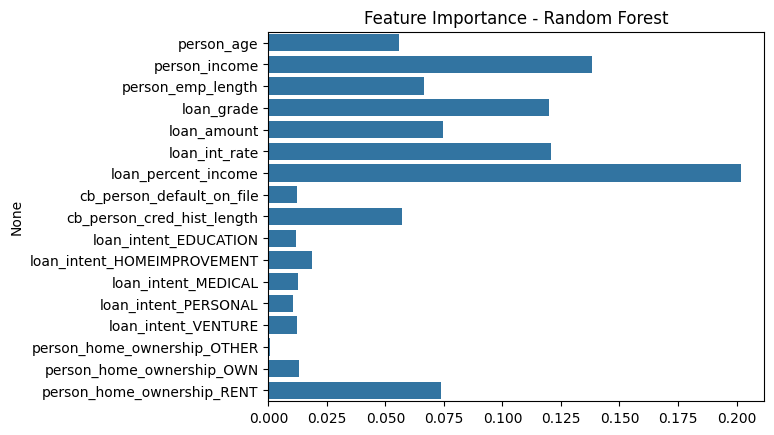

In [28]:
##Feature Importance Analysis

importances = rf_smote.feature_importances_
feat_names = X_train.columns
sns.barplot(x=importances, y=feat_names)
plt.title("Feature Importance - Random Forest")
plt.show()

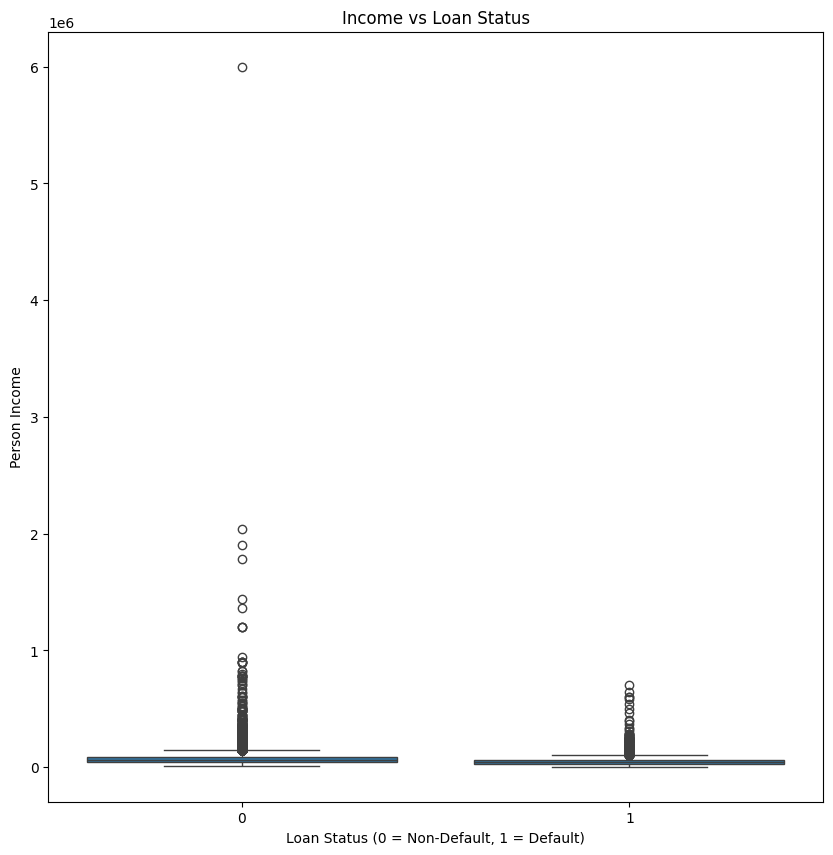

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,10))
sns.boxplot(data=df, x='loan_status', y='person_income')
plt.title('Income vs Loan Status')
plt.xlabel('Loan Status (0 = Non-Default, 1 = Default)')
plt.ylabel('Person Income')
plt.show()

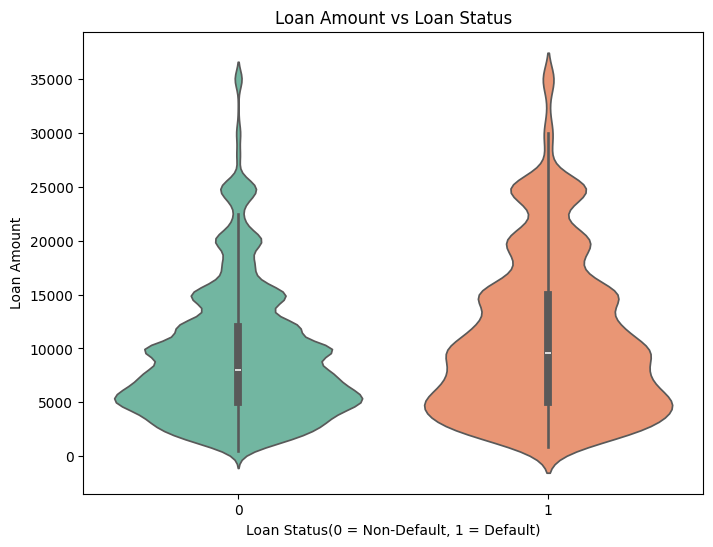

In [30]:

plt.figure(figsize=(8,6))
sns.violinplot(data=df, x='loan_status', y='loan_amount', hue='loan_status', palette="Set2", legend=False)
plt.title('Loan Amount vs Loan Status')
plt.xlabel('Loan Status(0 = Non-Default, 1 = Default)')
plt.ylabel('Loan Amount')
plt.show()


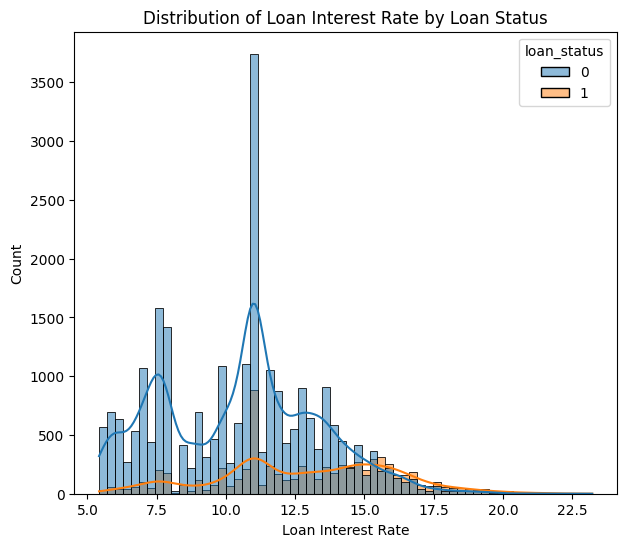

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,6))
sns.histplot(data=df, x='loan_int_rate', hue='loan_status', kde=True)
plt.title('Distribution of Loan Interest Rate by Loan Status')
plt.xlabel('Loan Interest Rate')
plt.ylabel('Count')
plt.show()

              precision    recall  f1-score   support

           0       0.93      0.79      0.85      7642
           1       0.51      0.78      0.61      2133

    accuracy                           0.79      9775
   macro avg       0.72      0.78      0.73      9775
weighted avg       0.84      0.79      0.80      9775

[[6045 1597]
 [ 477 1656]]
ROC-AUC: 0.8651615980136912


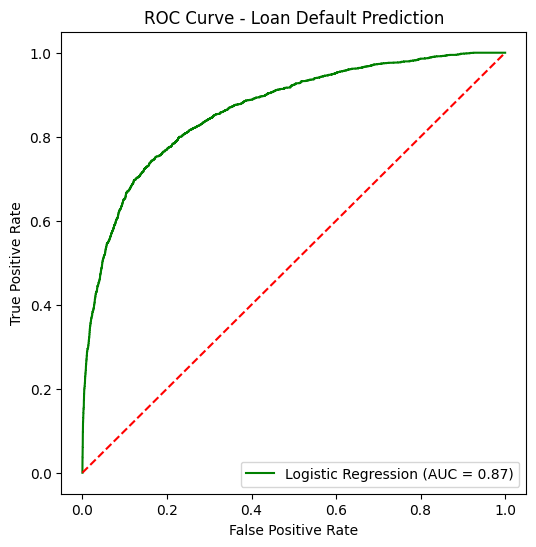

In [32]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_res, y_train_res)


y_pred_log = log_reg.predict(X_test)


print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:,1]))


y_proba_log = log_reg.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_proba_log)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='green', label=f'Logistic Regression (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Loan Default Prediction')
plt.legend(loc="lower right")
plt.show()

XGBoost Classifier Results:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7642
           1       0.95      0.73      0.82      2133

    accuracy                           0.93      9775
   macro avg       0.94      0.86      0.89      9775
weighted avg       0.93      0.93      0.93      9775

[[7564   78]
 [ 581 1552]]
ROC-AUC: 0.9388169089983512


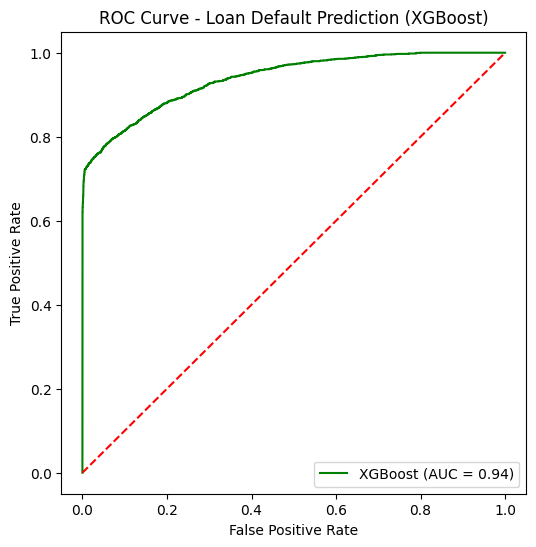

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from xgboost import XGBClassifier


xgb_model = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                          random_state=42, eval_metric='logloss')
xgb_model.fit(X_train_res, y_train_res)


y_pred_xgb = xgb_model.predict(X_test)


print("XGBoost Classifier Results:")
print(classification_report(y_test, y_pred_xgb))
print(confusion_matrix(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:,1]))


y_proba_xgb = xgb_model.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = auc(fpr_xgb, tpr_xgb)

plt.figure(figsize=(6,6))
plt.plot(fpr_xgb, tpr_xgb, color='green', label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Loan Default Prediction (XGBoost)')
plt.legend(loc="lower right")
plt.show()

[LightGBM] [Info] Number of positive: 17831, number of negative: 17831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009183 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1810
[LightGBM] [Info] Number of data points in the train set: 35662, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Classifier Results:
              precision    recall  f1-score   support

           0       0.93      0.99      0.96      7642
           1       0.96      0.74      0.83      2133

    accuracy                           0.94      9775
   macro avg       0.95      0.86      0.90      9775
weighted avg       0.94      0.94      0.93      9775

[[7575   67]
 [ 561 1572]]
ROC-AUC: 0.9483731857638217


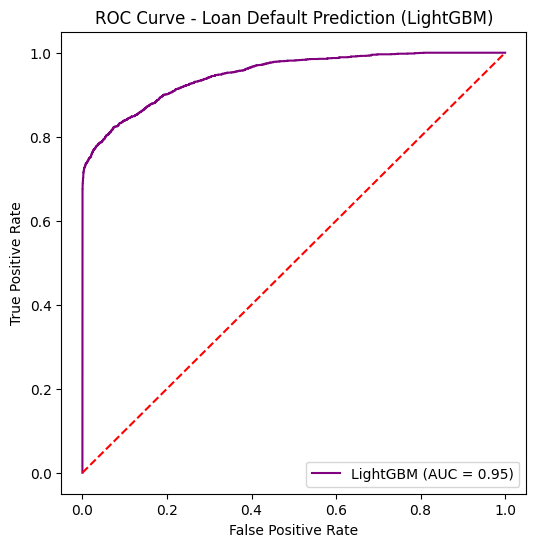

In [34]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(n_estimators=200, random_state=42)
lgbm_model.fit(X_train_res, y_train_res)

y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM Classifier Results:")
print(classification_report(y_test, y_pred_lgbm))
print(confusion_matrix(y_test, y_pred_lgbm))
print("ROC-AUC:", roc_auc_score(y_test, lgbm_model.predict_proba(X_test)[:,1]))

y_proba_lgbm = lgbm_model.predict_proba(X_test)[:,1]
fpr_lgbm, tpr_lgbm, thresholds_lgbm = roc_curve(y_test, y_proba_lgbm)
roc_auc_lgbm = auc(fpr_lgbm, tpr_lgbm)

plt.figure(figsize=(6,6))
plt.plot(fpr_lgbm, tpr_lgbm, color='purple', label=f'LightGBM (AUC = {roc_auc_lgbm:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Loan Default Prediction (LightGBM)')
plt.legend(loc="lower right")
plt.show()

[LightGBM] [Info] Number of positive: 17831, number of negative: 17831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008867 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1810
[LightGBM] [Info] Number of data points in the train set: 35662, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


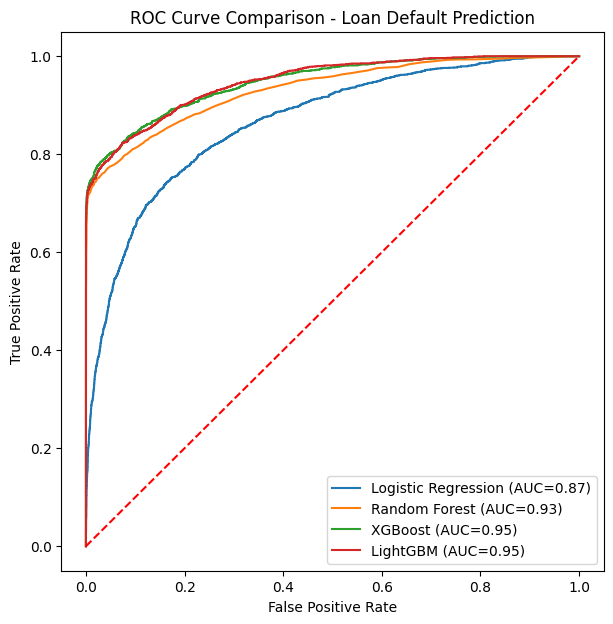

                 Model  Accuracy  Precision (Default)  Recall (Default)  \
0  Logistic Regression  0.787826             0.509069          0.776371   
1        Random Forest  0.930026             0.921466          0.742616   
2              XGBoost  0.935448             0.942285          0.750117   
3             LightGBM  0.935754             0.959121          0.736990   

   F1 (Default)   ROC-AUC  
0      0.614928  0.865162  
1      0.822430  0.932338  
2      0.835291  0.947691  
3      0.833510  0.948373  


In [35]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

log_reg = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss')
lgbm = LGBMClassifier(n_estimators=200, random_state=42)

models = {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

results = []

plt.figure(figsize=(7,7))

for name, model in models.items():

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]


    auc_score = roc_auc_score(y_test, y_proba)
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision (Default)": report["1"]["precision"],
        "Recall (Default)": report["1"]["recall"],
        "F1 (Default)": report["1"]["f1-score"],
        "ROC-AUC": auc_score
    })


    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.2f})')


plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Loan Default Prediction')
plt.legend(loc="lower right")
plt.show()


df_results = pd.DataFrame(results)
print(df_results)

In [36]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_res, y_train_res)

print("Best Parameters:", grid_search.best_params_)
print("Best ROC-AUC (CV):", grid_search.best_score_)

best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred_best))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_best))

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
Best ROC-AUC (CV): 0.9804519967107631
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      7642
           1       0.96      0.74      0.84      2133

    accuracy                           0.94      9775
   macro avg       0.94      0.87      0.90      9775
weighted avg       0.94      0.94      0.93      9775

Confusion Matrix:
 [[7569   73]
 [ 547 1586]]
Test ROC-AUC: 0.9484925080915262


In [37]:
from sklearn.model_selection import GridSearchCV
from lightgbm import LGBMClassifier

lgbm_base = LGBMClassifier(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'num_leaves': [31, 50, 70],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 5, 10],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_search_lgbm = GridSearchCV(
    estimator=lgbm_base,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search_lgbm.fit(X_train_res, y_train_res)

print("Best Parameters (LightGBM):", grid_search_lgbm.best_params_)
print("Best ROC-AUC (CV):", grid_search_lgbm.best_score_)

best_lgbm = grid_search_lgbm.best_estimator_
y_pred_best_lgbm = best_lgbm.predict(X_test)
y_proba_best_lgbm = best_lgbm.predict_proba(X_test)[:,1]

print("Classification Report:\n", classification_report(y_test, y_pred_best_lgbm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best_lgbm))
print("Test ROC-AUC:", roc_auc_score(y_test, y_proba_best_lgbm))

Fitting 3 folds for each of 324 candidates, totalling 972 fits
[LightGBM] [Info] Number of positive: 17831, number of negative: 17831
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009428 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1810
[LightGBM] [Info] Number of data points in the train set: 35662, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best Parameters (LightGBM): {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 300, 'num_leaves': 70, 'subsample': 0.8}
Best ROC-AUC (CV): 0.9809918809667671
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.99      0.96      7642
           1       0.95      0.74      0.83      2133

    accuracy                           0.94    

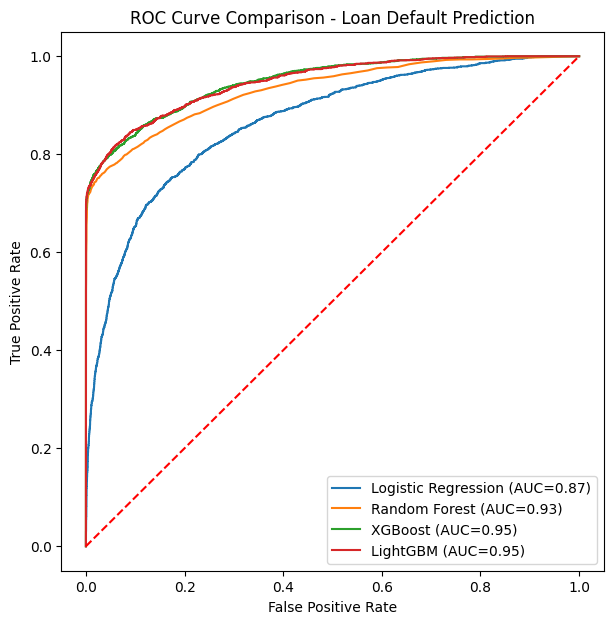

                 Model  Accuracy  Precision (Default)  Recall (Default)  \
0  Logistic Regression  0.787826             0.509069          0.776371   
1        Random Forest  0.930026             0.921466          0.742616   
2              XGBoost  0.936573             0.955998          0.743554   
3             LightGBM  0.935141             0.949071          0.742616   

   F1 (Default)   ROC-AUC  
0      0.614928  0.865162  
1      0.822430  0.932338  
2      0.836498  0.948493  
3      0.833246  0.948055  


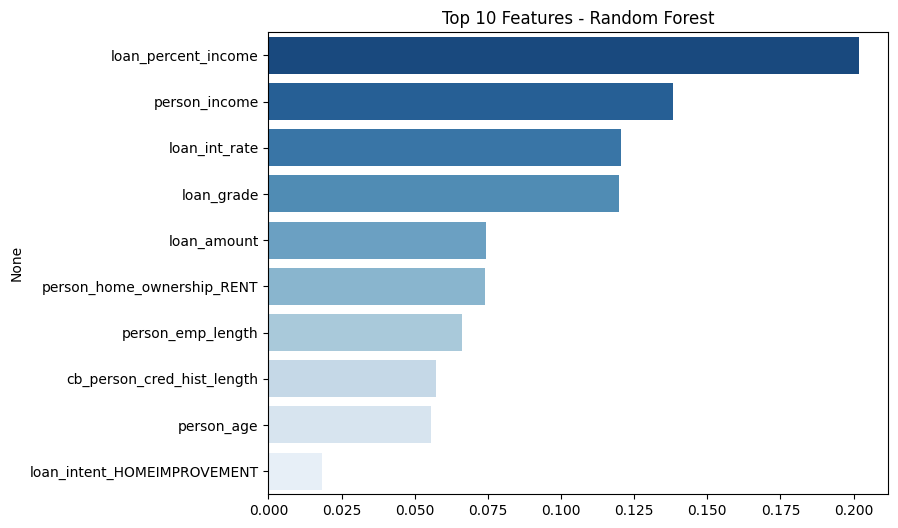

<Figure size 800x600 with 0 Axes>

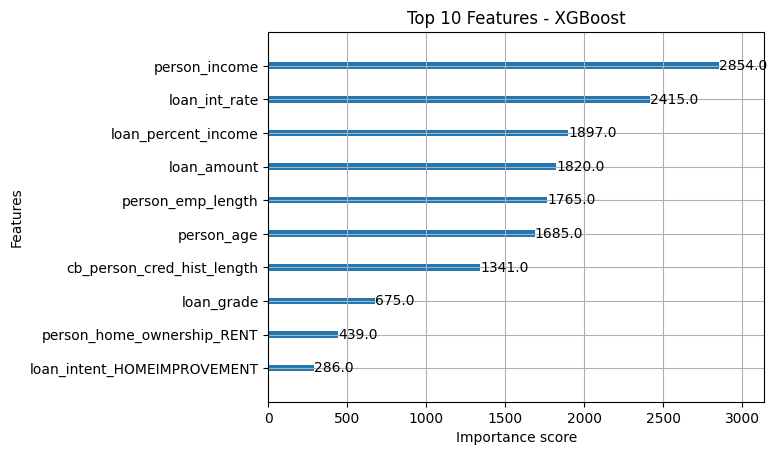

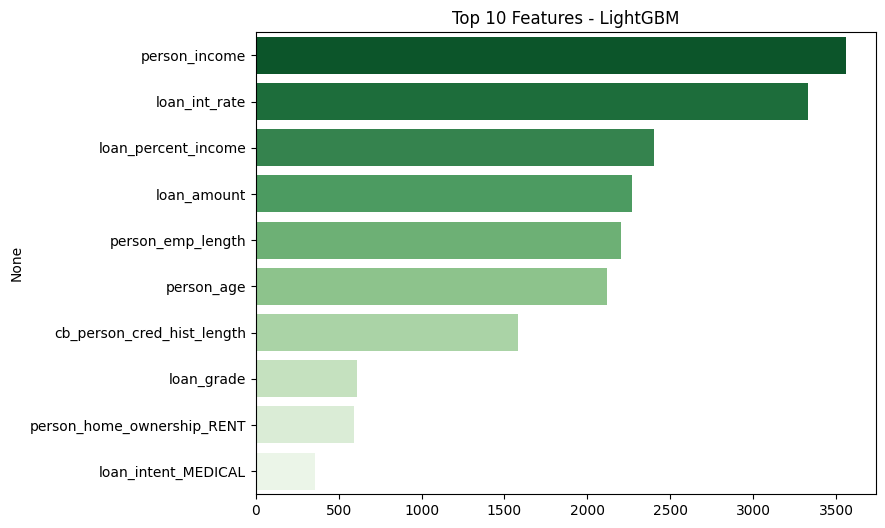

In [38]:
## Conclusion & Key Insights

# --- ROC Curve Comparison ---
plt.figure(figsize=(7,7))

for name, model in {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC={auc_score:.2f})')

plt.plot([0,1],[0,1],'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison - Loan Default Prediction')
plt.legend(loc="lower right")
plt.show()

# --- Metrics Table ---
results = []
for name, model in {
    "Logistic Regression": log_reg,
    "Random Forest": rf,
    "XGBoost": best_xgb,
    "LightGBM": best_lgbm
}.items():
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:,1]
    report = classification_report(y_test, y_pred, output_dict=True)
    results.append({
        "Model": name,
        "Accuracy": report["accuracy"],
        "Precision (Default)": report["1"]["precision"],
        "Recall (Default)": report["1"]["recall"],
        "F1 (Default)": report["1"]["f1-score"],
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

df_results = pd.DataFrame(results)
print(df_results)

# --- Feature Importance Comparison ---
# Random Forest
rf_importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=rf_importances.values[:10], y=rf_importances.index[:10], hue=rf_importances.index[:10], palette="Blues_r", legend=False)
plt.title("Top 10 Features - Random Forest")
plt.show()

# XGBoost
from xgboost import plot_importance
plt.figure(figsize=(8,6))
plot_importance(best_xgb, max_num_features=10, importance_type='weight')
plt.title("Top 10 Features - XGBoost")
plt.show()

# LightGBM
lgbm_importances = pd.Series(best_lgbm.feature_importances_, index=X_train.columns).sort_values(ascending=False)
plt.figure(figsize=(8,6))
sns.barplot(x=lgbm_importances.values[:10], y=lgbm_importances.index[:10], hue=lgbm_importances.index[:10], palette="Greens_r", legend=False)
plt.title("Top 10 Features - LightGBM")
plt.show()